# The Santander audit: is the ESA classification a good enough voter?

This notebook records a piece of commissioned homework: check whether
the ESA scene classification (SCL) that ships with every Sentinel-2
product can serve as the wet/dry voter for the transition map, using
the Bay of Santander as the test case. The audit escalated twice —
first when a plain low-tide photograph contradicted both maps in the
central flats, then when the recovered area turned out to contain
salt marsh, which no wet/dry vote can see — and it ended with a
revised production rule and a measured sampling limit.

A note on provenance: this exploration predates the experiments/
discipline, and its original scratch scripts were not preserved. What
was preserved are the sealed artifacts each stage produced
(`results/santander_*`), and every number and map below is recomputed
from them; the dated narrative lives in `docs/PHASE_LOG.md`.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# run from the repo root so the results/ paths resolve
here = Path.cwd()
while not (here / "pyintertidal").is_dir():
    if here.parent == here:
        raise FileNotFoundError("repo root not found above " + str(Path.cwd()))
    here = here.parent
os.chdir(here)

def ha(mask):
    """10 m pixels -> hectares."""
    return float(mask.sum()) * 0.01

## 1. SCL vs NDWI as the transition-map voter
Two reference maps of the same bay, built with identical machinery and
one difference: who votes wet/dry per scene. Classes: 0 = transition
(intertidal candidate), 1 = stable water, 2 = stable land. The failure
mode to look for: turbid, shallow water over bright mud reads as
"stable water" to the SCL, permanently — and a pixel the reference
calls stable water can never be readmitted by the pipeline.

overall map agreement: 80.9%
NDWI transition area: 2,851 ha
of which the SCL calls STABLE WATER (unrecoverable): 293 ha = 10%


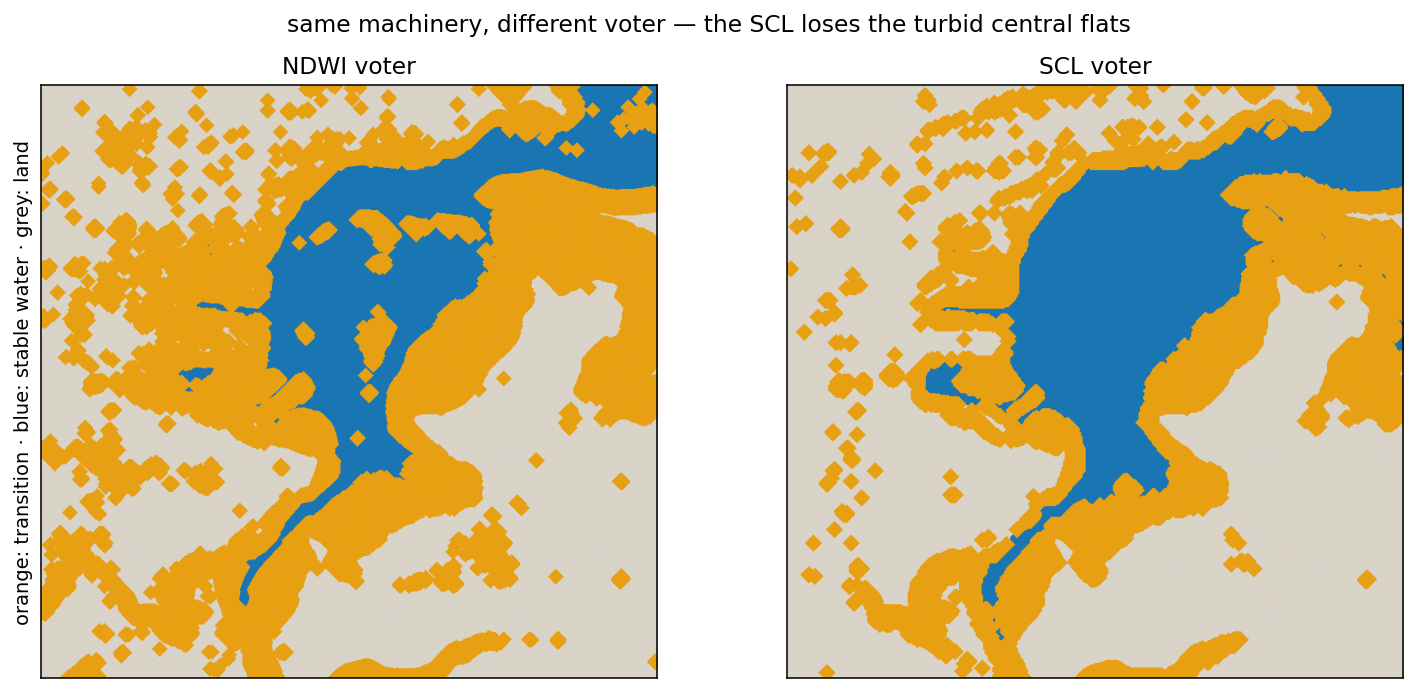

In [2]:
d = np.load("results/santander_scl_vs_ndwi.npz")
ndwi, scl = d["ndwi"], d["scl"]
agree = float((ndwi == scl).mean())
trans_ndwi = ndwi == 0
swallowed = trans_ndwi & (scl == 1)
print(f"overall map agreement: {100*agree:.1f}%")
print(f"NDWI transition area: {ha(trans_ndwi):,.0f} ha")
print(f"of which the SCL calls STABLE WATER (unrecoverable): "
      f"{ha(swallowed):,.0f} ha = {100*swallowed.sum()/trans_ndwi.sum():.0f}%")

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#e8a013", "#1a76b3", "#d9d3c8"])
fig, ax = plt.subplots(1, 2, figsize=(11, 5), dpi=140)
for a, m, t in ((ax[0], ndwi, "NDWI voter"), (ax[1], scl, "SCL voter")):
    a.imshow(m, cmap=cmap, vmin=0, vmax=2, origin="upper")
    a.set_title(t)
    a.set_xticks([]); a.set_yticks([])
ax[0].set_ylabel("orange: transition · blue: stable water · grey: land")
fig.suptitle("same machinery, different voter — the SCL loses the turbid "
             "central flats", y=0.98)
fig.tight_layout()

Verdict (also in the phase log): the NDWI stays as the voter; the SCL
is demoted to cloud gatekeeper only. The disagreement was first
noticed not in any metric but in a low-tide photograph of the bay —
the central flats were visibly larger than either map claimed, which
triggered the rest of this audit.

## 2. The marsh gap
Part of the missing area was not a voting problem at all: salt marsh.
Vegetation stands above the water it floods in, so a wet/dry vote
cannot see the flooding — the canopy hides it. The package's marsh
detector (`pyintertidal.marsh`: flooded vegetation via MNDWI, which
uses the short-wave infrared that penetrates the canopy) was run on
the multiband cube:

marsh detected: 141 ha (median flooded-vegetation frequency inside: 0.10)


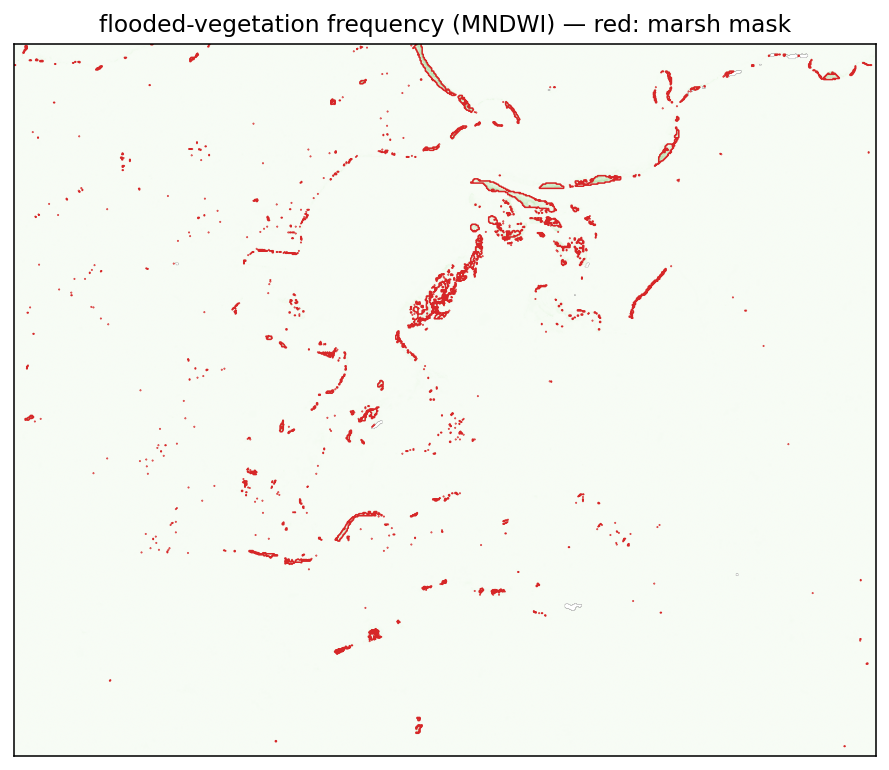

In [3]:
m = np.load("results/santander_marsh.npz")
print(f"marsh detected: {ha(m['mask']):,.0f} ha "
      f"(median flooded-vegetation frequency inside: "
      f"{np.nanmedian(np.where(m['mask'], m['f_marsh'], np.nan)):.2f})")

fig, ax = plt.subplots(figsize=(7.5, 5.6), dpi=140)
ax.imshow(m["f_marsh"], cmap="Greens", vmin=0, vmax=1, origin="upper")
ax.contour(m["mask"].astype(float), levels=[0.5], colors="#d62728",
           linewidths=0.8)
ax.set_title("flooded-vegetation frequency (MNDWI) — red: marsh mask")
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

An honesty bug caught along the way, now queued as a fix: the working
cube has no SWIR band, and the marsh step silently produced an EMPTY
layer instead of declaring "no SWIR → marsh not assessed". Silence
and a negative result must never look the same.

## 3. Witness scenes and the glint lesson
For the flats themselves the question became: which pixels has
the archive *ever* actually seen dry? Candidate witnesses come
from the extreme-low-tide scenes — but one scene is not
evidence: sun glint on the water surface can fake \"dry\" in a
single image, and the naive union of the five lowest scenes
turned out to be heavily contaminated by exactly that. The
vetting rule — **dry in at least 2 of the 5 lowest scenes** —
cuts the suspect half away. Production readmission then
additionally requires hydraulic connection to the known
intertidal (water must be able to reach a pixel for its
wet/dry record to mean anything); the final accounting of the
v2 map is in the phase log, and its sealed render is below.
(One earlier, more permissive recovery attempt is also kept in
`results/santander_recovery.npz` — superseded by this rule.)


In [4]:
naive = np.load("results/santander_witness2.npz")["witness2"]
vet = np.load("results/santander_witness_vetted.npz")["witness2"]
flats = np.load("results/santander_missing.npz")["flats"]
print(f"naive witness union (dry in ANY of the 5 lowest scenes): "
      f"{ha(naive):>7,.0f} ha")
print(f"vetted witness (dry in at least 2 of the 5):             "
      f"{ha(vet):>7,.0f} ha")
print(f"removed by the 2-of-5 rule (glint suspects):             "
      f"{ha(naive) - ha(vet):>7,.0f} ha "
      f"({100*(1 - vet.sum()/naive.sum()):.0f}% of the union)")
print()
print(f"flats in the map at audit time:                          "
      f"{ha(flats):>7,.0f} ha")
print(f"vetted witness BEYOND the map (readmission candidates):  "
      f"{ha(vet & ~flats):>7,.0f} ha")

naive witness union (dry in ANY of the 5 lowest scenes):   2,341 ha
vetted witness (dry in at least 2 of the 5):               1,157 ha
removed by the 2-of-5 rule (glint suspects):               1,183 ha (51% of the union)

flats in the map at audit time:                            1,164 ha
vetted witness BEYOND the map (readmission candidates):      216 ha


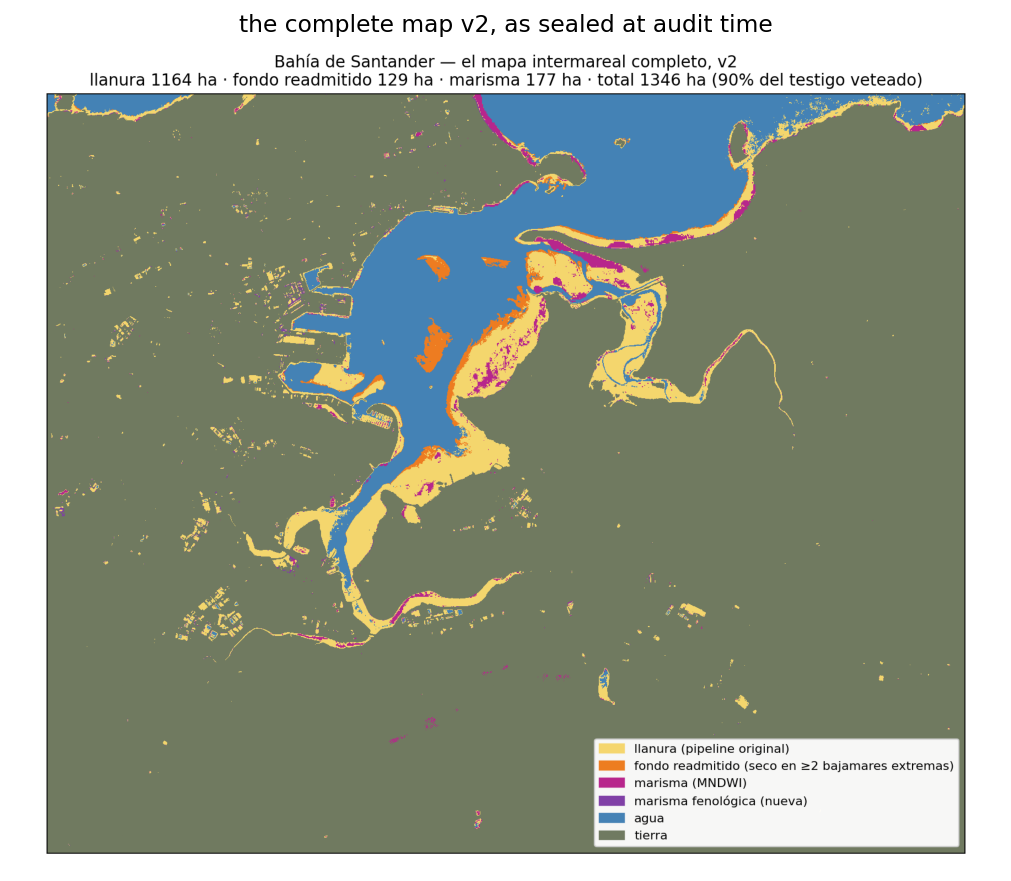

In [5]:
import matplotlib.image as mpimg
img = mpimg.imread("results/santander_complete_v2.png")
fig, ax = plt.subplots(figsize=(9.5, 6.4), dpi=140)
ax.imshow(img)
ax.axis("off")
ax.set_title("the complete map v2, as sealed at audit time")
fig.tight_layout()

## 4. What still cannot be seen — and why that is measured, not blamed
Even the vetted witness does not cover everything the low-tide
photographs show. The remainder is a *sampling* limit of any
sun-synchronous satellite (see the sampling figure in the README and
the alias table of notebook 01): the lunar tide drifts past the fixed
overpass hour and eventually shows all its phases, but the solar
constituent S2 is frozen at one phase forever — and the extreme lows
that expose the deepest banks need both constituents at their minima
at the same time. Part of that band becomes visible with more years of
archive; a floor of roughly two tens of centimetres never does. The
map declares that band instead of interpolating it — on nearly flat
banks, a few centimetres of tide hide a lot of surface, so an
interpolated guess there would be confidently wrong.